Bilkul possible hai bhai 👍

Tumhare screenshot me jo list hai (Linear Regression, Logistic Regression, Decision Trees, Random Forest, Gradient Boosting, KNN, SVM, Naive Bayes, K-Means, DBSCAN) — in sab pe ek **comparison project** banaya jaa sakta hai. Ye ek **Machine Learning Algorithms Benchmarking Project** ban jayega.

---

### 🔹 Project Idea: Algorithm Comparison

1. **Dataset choose karo**

   * Classification ke liye: Iris, Titanic, Breast Cancer dataset
   * Regression ke liye: Boston Housing, California Housing
   * Clustering ke liye: Synthetic datasets (scikit-learn ke `make_blobs` ya `make_moons`)

2. **Algorithms apply karo**

   * Classification: Logistic Regression, KNN, SVM, Decision Trees, Random Forest, Gradient Boosting, Naive Bayes
   * Regression: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor
   * Clustering: K-Means, DBSCAN

3. **Compare metrics**

   * Classification: Accuracy, Precision, Recall, F1-score, ROC-AUC
   * Regression: MSE, RMSE, MAE, R² score
   * Clustering: Silhouette score, Davies-Bouldin index

4. **Visualization**

   * Accuracy/F1-score ko bar chart me dikhana
   * Training time vs accuracy plot karna
   * Clustering results ka scatter plot

5. **Result**

   * Ek summary table bana ke show karo:
     | Algorithm | Accuracy | F1 | Training Time | Remarks |

---

👉 Isse tumhe har algorithm ka **math + code + performance comparison** clear ho jayega.
Ye ek **portfolio-level project** banega jo resume me dikhane layak hoga 🚀

---

Kya tum chahte ho ki main tumhe iska **Python (scikit-learn) code ka base template** bana kar de du jisme bas dataset badal ke sab algo compare ho jaye?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("import successfully ml algorithm ✅")

import successfully ml algorithm ✅


In [2]:
df = pd.read_csv("/content/Housing.csv")
print("Load successfully housing dataset for Regression✅ ")
df1 = pd.read_csv("/content/Iris.csv")
print("Load successfully Iris dataset  for Classifiction ✅  ")
print("Waiting for clustering dataset 🫸   ")

Load successfully housing dataset for Regression✅ 
Load successfully Iris dataset  for Classifiction ✅  
Waiting for clustering dataset 🫸   


In [3]:
df1.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

In [5]:
# 💡 Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [6]:
# ============================================
# 2️⃣ EDA - Basic Checks
# ============================================
print(df1.head(), "\n")
print(df1.info(), "\n")
print(df1.describe(), "\n")
print("Missing values:\n", df1.isna().sum(), "\n")

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None 

           

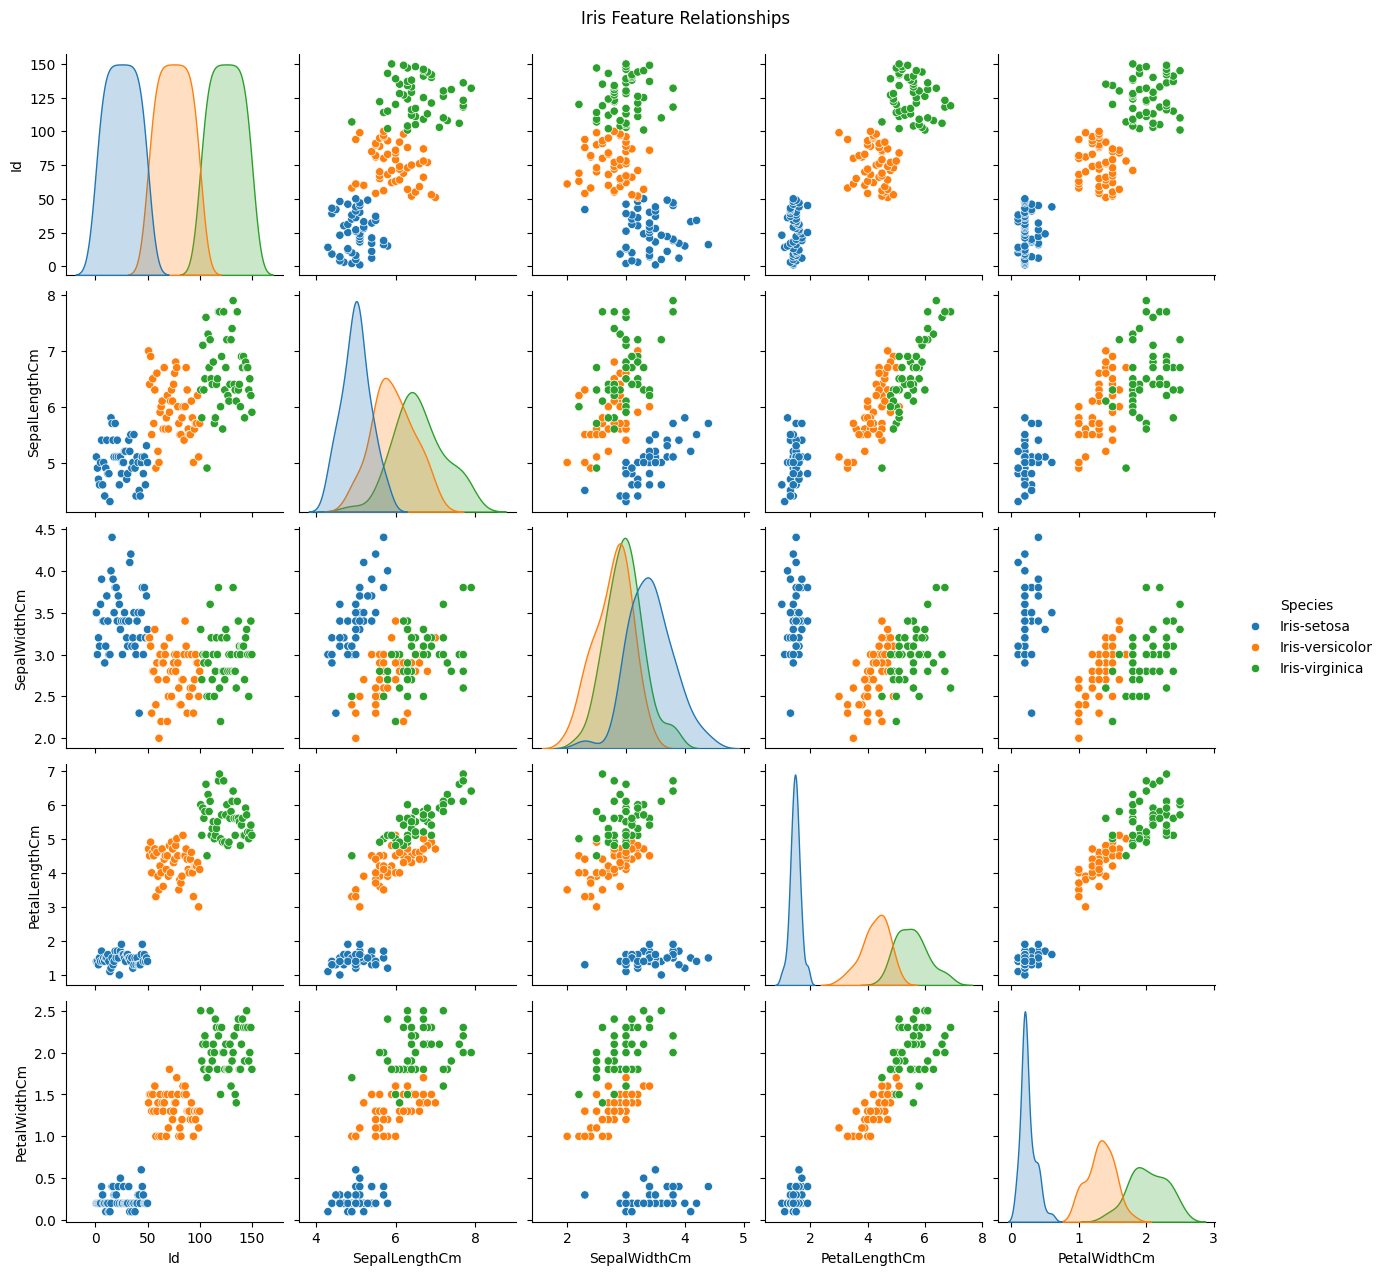

In [7]:
# Optional Pairplot
sns.pairplot(df1, hue="Species")
plt.suptitle("Iris Feature Relationships", y=1.02)
plt.show()

In [8]:
# ============================================
# 3️⃣ Label Encoding
# ============================================
le = LabelEncoder()
df1["Species_encoded"] = le.fit_transform(df1["Species"])
print("✅ Label Encoding Done")
print(df1[["Species", "Species_encoded"]].head(), "\n")

✅ Label Encoding Done
       Species  Species_encoded
0  Iris-setosa                0
1  Iris-setosa                0
2  Iris-setosa                0
3  Iris-setosa                0
4  Iris-setosa                0 



In [9]:

# ============================================
# 4️⃣ Feature & Target Split
# ============================================
X = df1.drop(["Id", "Species", "Species_encoded"], axis=1)
y = df1["Species_encoded"]

In [10]:
# ============================================
# 5️⃣ Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
# ============================================
# 6️⃣ Feature Scaling
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# ============================================
# 7️⃣ Define Models
# ============================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

In [13]:
# ============================================
# 8️⃣ Train, Predict & Evaluate
# ============================================
results = []

for name, model in models.items():
    print(f"🔹 Training {name} ...")

    # Tree-based models don't need scaling
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting", "Naive Bayes"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    print(f"{name} Results:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

🔹 Training Logistic Regression ...
Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

------------------------------------------------------------
🔹 Training KNN ...
KNN Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

------------------------------------------------------------
🔹 Training SVM (RBF)

In [14]:
# ============================================
# 9️⃣ Compare All Model Results
# ============================================
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n🏆 Model Performance Summary:\n", df_results)



🏆 Model Performance Summary:
                  Model  Accuracy  Precision    Recall        F1
2            SVM (RBF)  0.966667   0.969697  0.966667  0.966583
5    Gradient Boosting  0.966667   0.969697  0.966667  0.966583
6          Naive Bayes  0.966667   0.969697  0.966667  0.966583
1                  KNN  0.933333   0.944444  0.933333  0.932660
0  Logistic Regression  0.933333   0.933333  0.933333  0.933333
3        Decision Tree  0.933333   0.933333  0.933333  0.933333
4        Random Forest  0.900000   0.902357  0.900000  0.899749


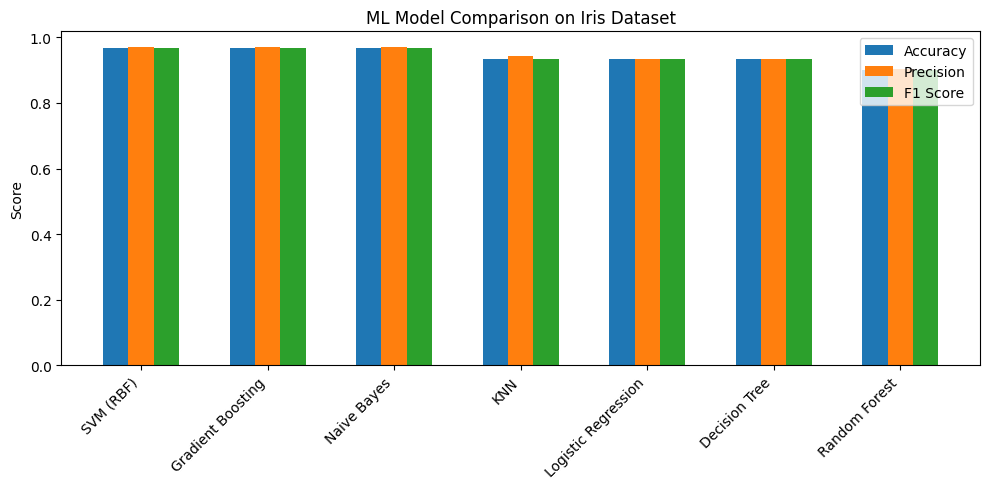

In [15]:
# ============================================
# 🔟 Plot Comparison Chart
# ============================================
plt.figure(figsize=(10, 5))
x = np.arange(len(df_results["Model"]))
width = 0.2

plt.bar(x - width, df_results["Accuracy"], width, label="Accuracy")
plt.bar(x, df_results["Precision"], width, label="Precision")
plt.bar(x + width, df_results["F1"], width, label="F1 Score")

plt.xticks(x, df_results["Model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("ML Model Comparison on Iris Dataset")
plt.legend()
plt.tight_layout()
plt.show()


🔥 Best Model: SVM (RBF)


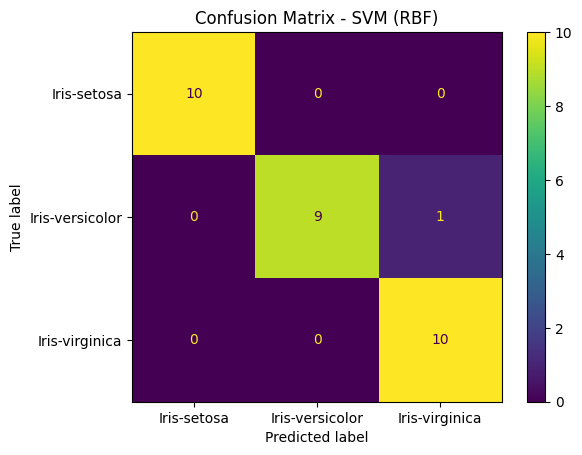

In [16]:

# ============================================
# 1️⃣1️⃣ Confusion Matrix for Best Model
# ============================================
best_model_name = df_results.iloc[0]["Model"]
best_model = models[best_model_name]

# Refit best model
if best_model_name in ["Decision Tree", "Random Forest", "Gradient Boosting", "Naive Bayes"]:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)
else:
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)

print(f"\n🔥 Best Model: {best_model_name}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=le.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

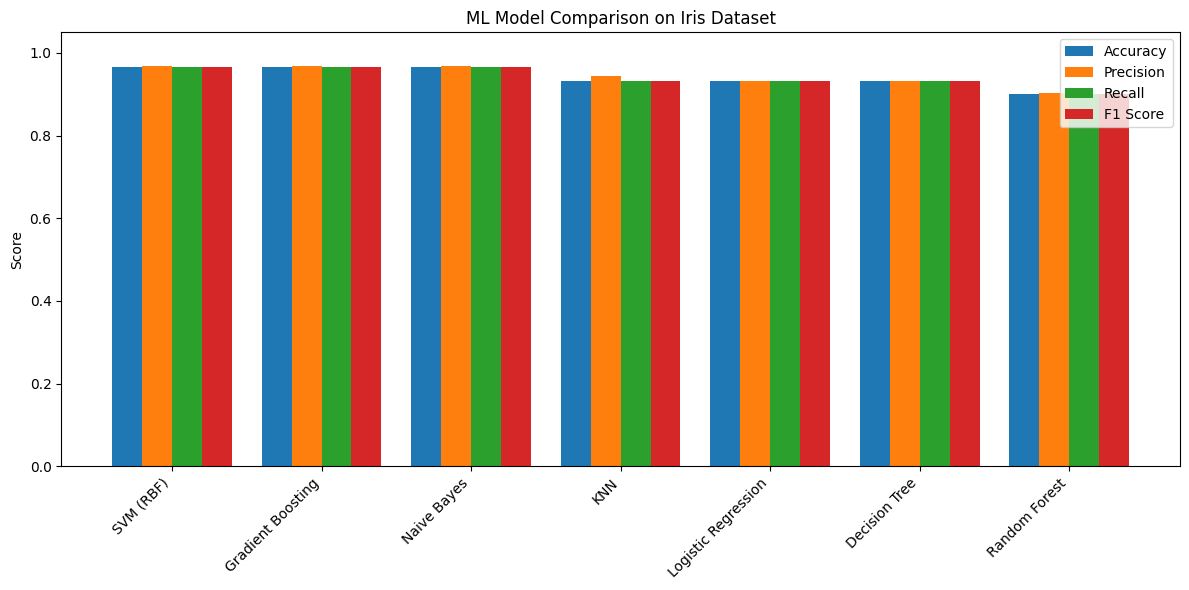

In [17]:
# ============================================
# 🔟 Plot Comparison Chart (with Recall)
# ============================================
plt.figure(figsize=(12, 6))
x = np.arange(len(df_results["Model"]))
width = 0.2

plt.bar(x - 1.5*width, df_results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, df_results["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, df_results["Recall"], width, label="Recall")  # Added Recall
plt.bar(x + 1.5*width, df_results["F1"], width, label="F1 Score")

plt.xticks(x, df_results["Model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("ML Model Comparison on Iris Dataset")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


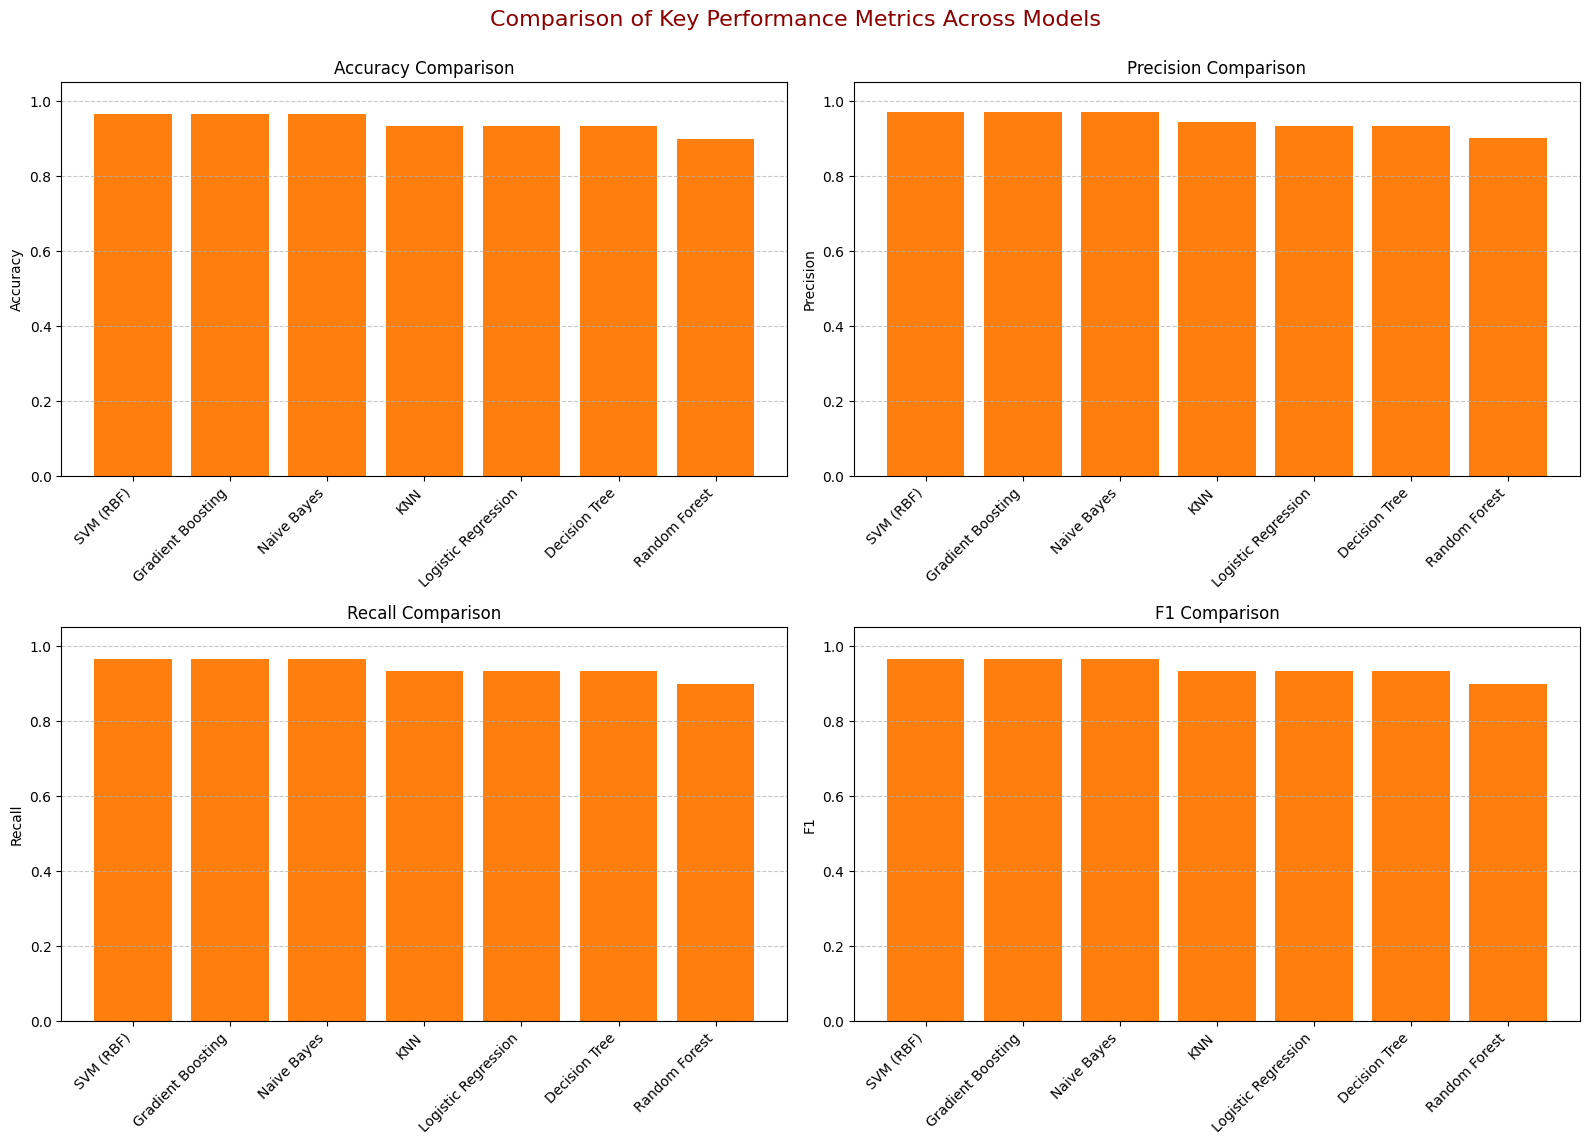

In [18]:
# ============================================
# 🔟 Separate Bar Charts for Each Metric
# ============================================
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors = ["#ffb347", "#1f77b4"]  # Orange for Oversampling, Blue for Undersampling (example)

plt.figure(figsize=(16, 12))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.bar(df_results["Model"], df_results[metric], color="#ff7f0e")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Comparison of Key Performance Metrics Across Models", fontsize=16, color="darkred", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### classification complet ✅👆

In [22]:
print("start Regression   🚲🥈")

start Regression   🚲🥈


In [20]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [35]:
# 💡 Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print("✅ Regression libraries imported successfully")


✅ Regression libraries imported successfully


In [36]:
# ============================================
# 2️⃣ EDA - Basic Checks
# ============================================
print(df.head(), "\n")
print(df.info(), "\n")
print(df.describe(), "\n")
print("Missing values:\n", df.isna().sum(), "\n")

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus PriceCategory  
0                 1    High Price  
1                 1    High Price  
2                 2    High Price  
3             

In [37]:
# use to pandas

yes_no_columns = ['guestroom','basement','hotwaterheating','airconditioning','prefarea',"mainroad"]

df[yes_no_columns] = df[yes_no_columns].replace({'yes':1, 'no':0})

df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,PriceCategory
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,High Price
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,High Price
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2,High Price
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,High Price
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,High Price


In [38]:
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':1,'semi-furnished':2, 'unfurnished':3})
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,PriceCategory
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,NaN,High Price
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,NaN,High Price
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,NaN,High Price
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,NaN,High Price
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,NaN,High Price


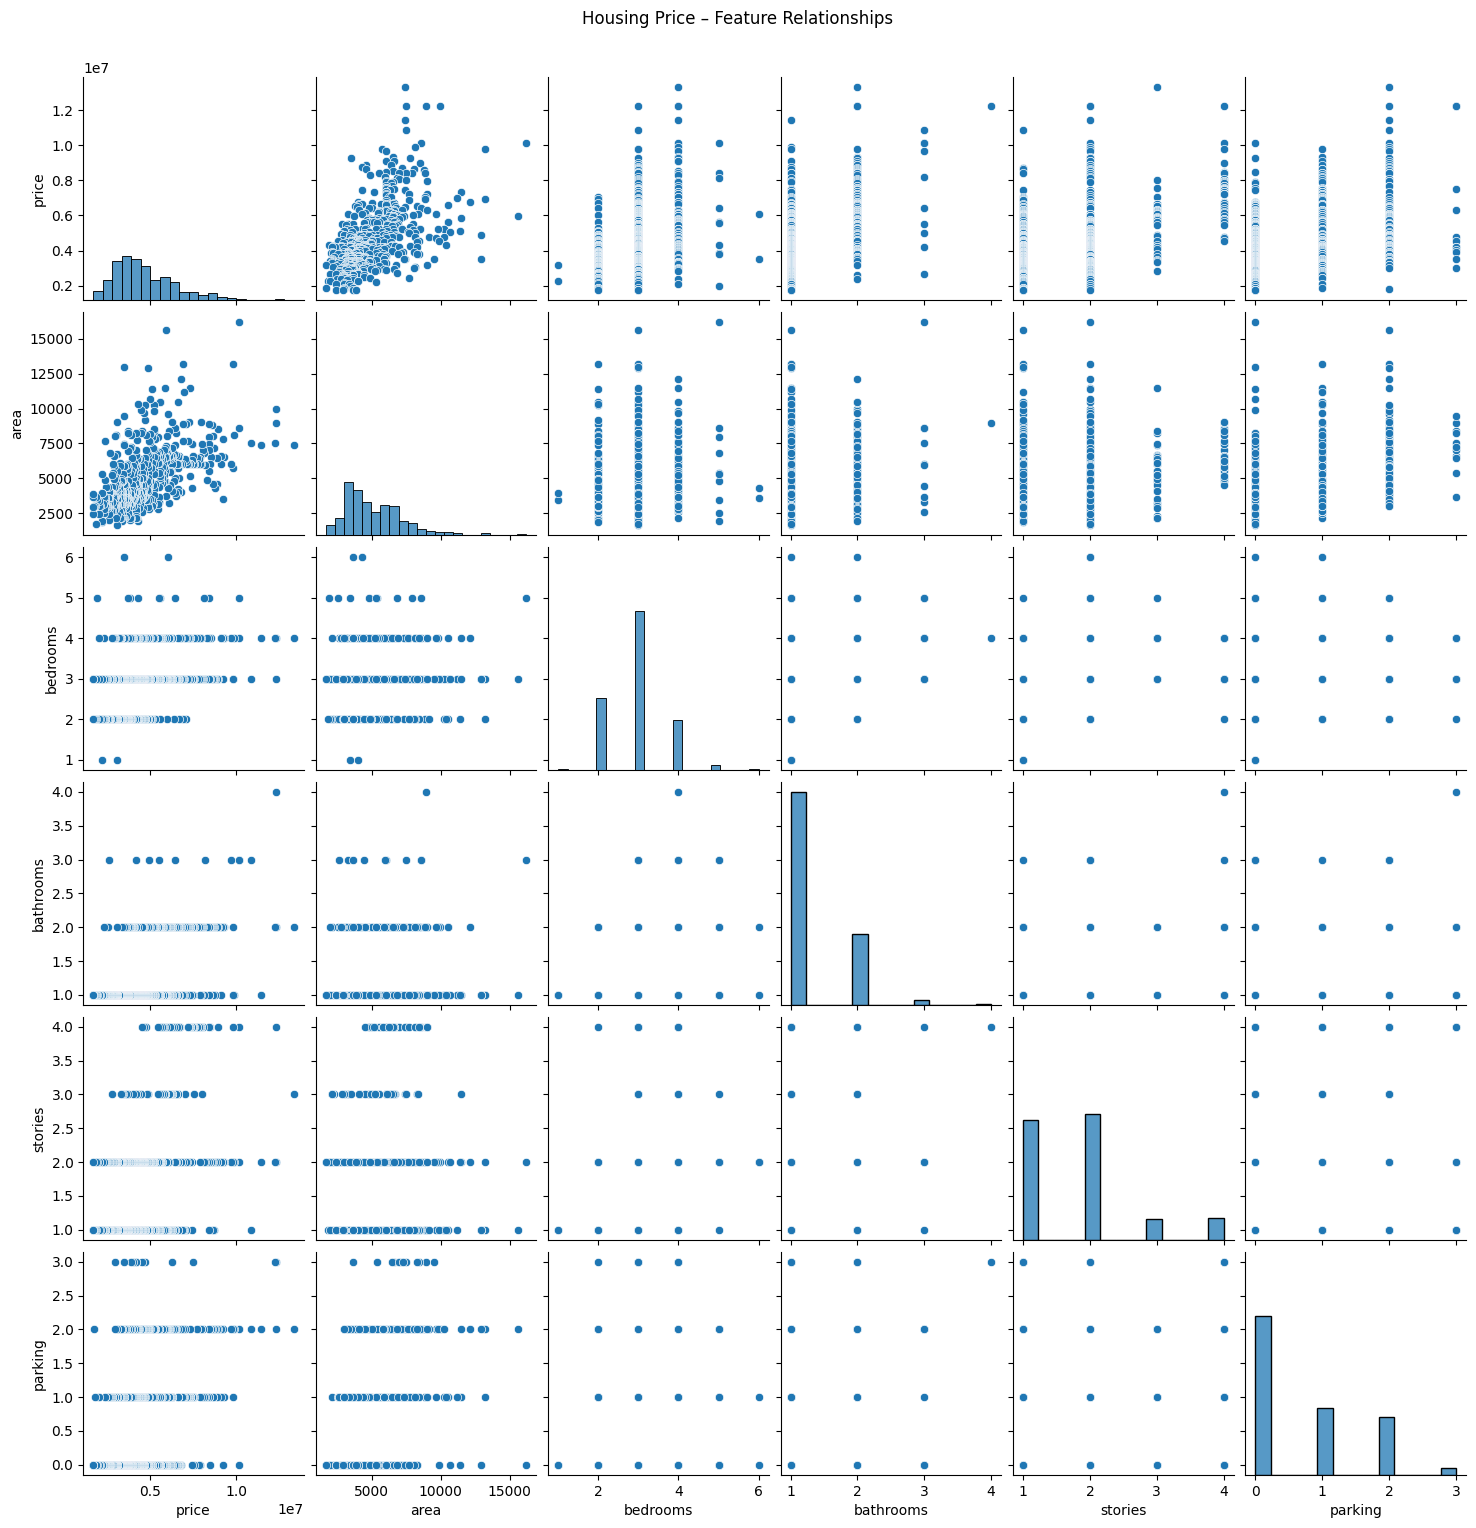

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]

sns.pairplot(df[cols])
plt.suptitle("Housing Price – Feature Relationships", y=1.02)
plt.show()


In [40]:
import pandas as pd

df["PriceCategory"] = pd.cut(
    df["price"],
    bins=3,
    labels=["Low Price", "Medium Price", "High Price"]
)


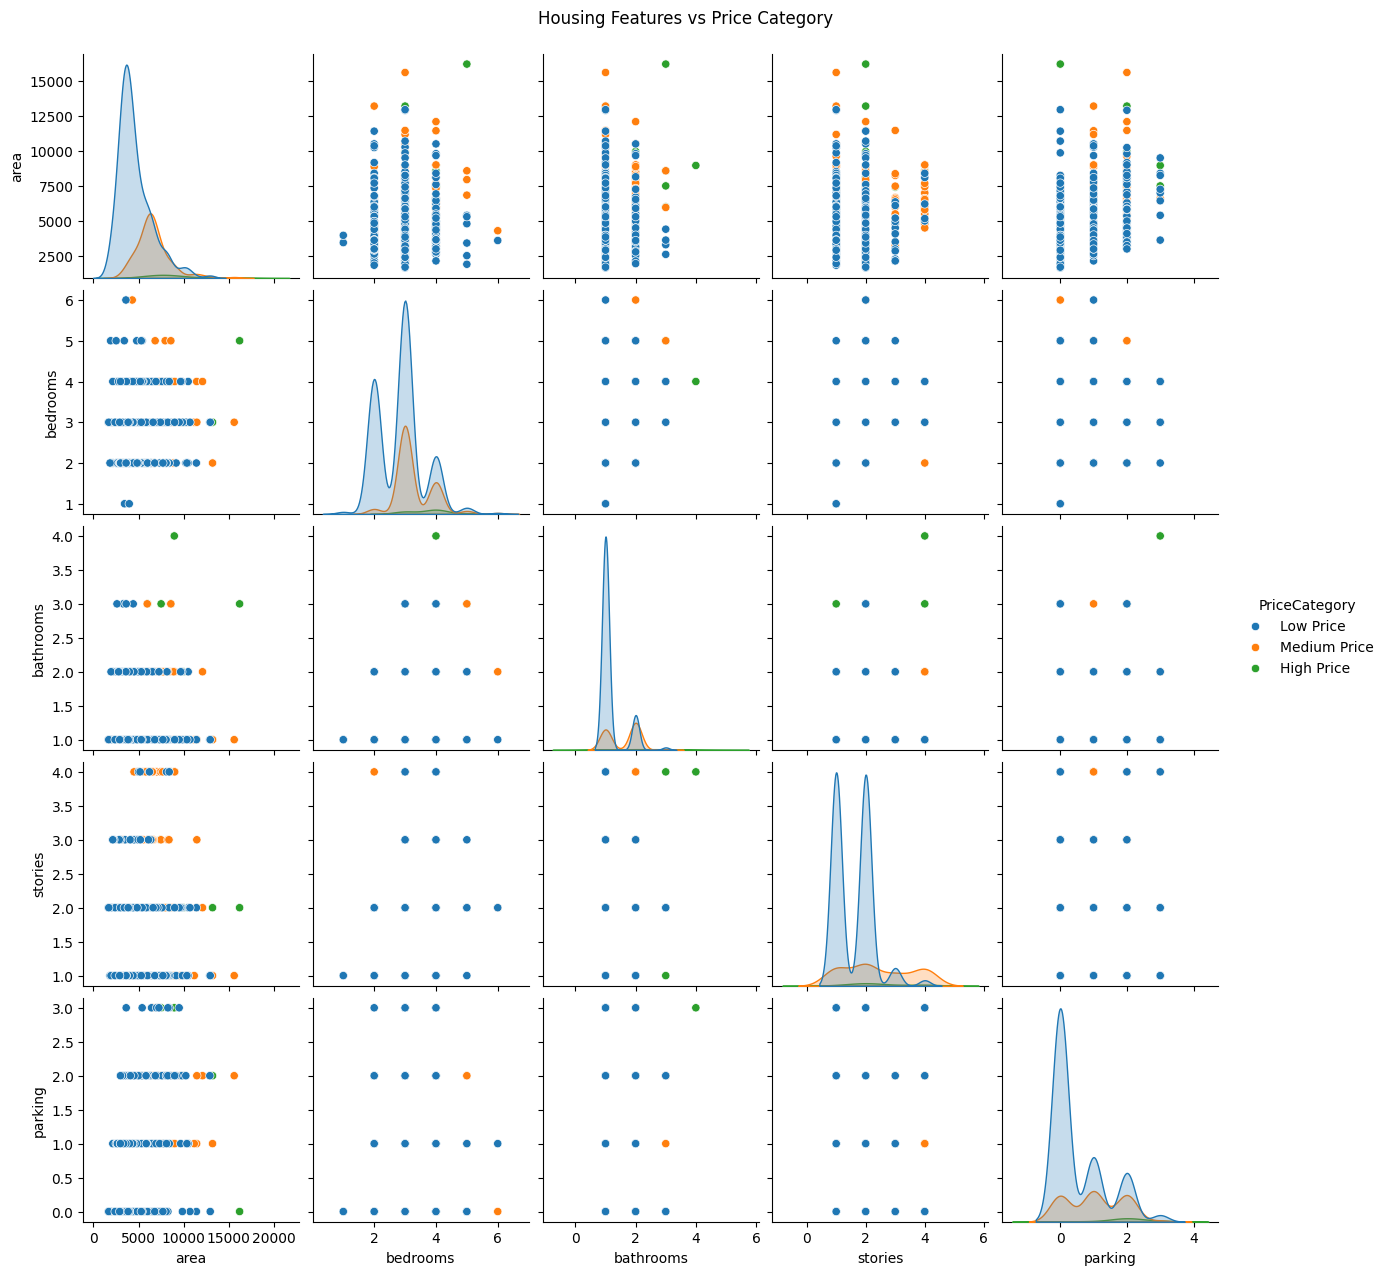

In [41]:
sns.pairplot(
    df,
    vars=["area", "bedrooms", "bathrooms", "stories", "parking"],
    hue="PriceCategory"
)
plt.suptitle("Housing Features vs Price Category", y=1.02)
plt.show()


In [42]:

# ============================================
# 4️⃣ Feature & Target Split
# ============================================
x=df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y=df['price']

In [44]:
# ============================================
# 5️⃣ Train-Test Split
# ============================================
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [53]:
# ============================================
# 6️⃣ Feature Scaling
# ============================================
scaler = StandardScaler()

# For distance-based models (SVR, KNN)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Tree-based models can use raw features
x_train_raw = x_train.copy()
x_test_raw = x_test.copy()

print("✅ Feature scaling done")


✅ Feature scaling done


In [54]:
# ============================================
# 6️⃣  Regression Models
# ============================================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

In [55]:
results = []

for name, model in models.items():

    if name in ["SVR", "KNN"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train_raw, y_train)
        y_pred = model.predict(x_test_raw)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 2)
    })



✅ Regression Metrics Comparison
               Model         MAE        RMSE    R2
0  Linear Regression  1127483.35  1514173.55  0.55
1      Decision Tree  1462106.06  2117872.03  0.11
2      Random Forest  1150445.33  1610415.54  0.49
3  Gradient Boosting  1122130.09  1548211.90  0.53
4                SVR  1763886.64  2359644.46 -0.10
5                KNN  1178763.14  1639327.71  0.47


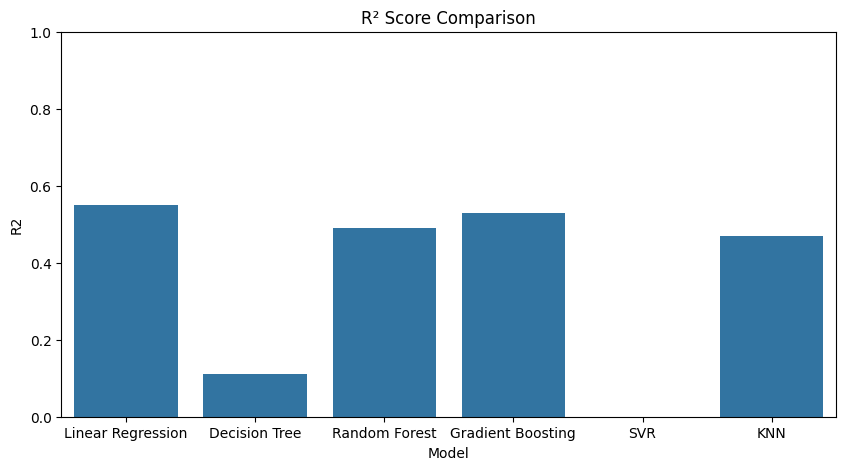

In [56]:
# ============================================
# 8  Results Table
# ============================================
results_df = pd.DataFrame(results)
print("\n✅ Regression Metrics Comparison")
print(results_df)

# Optional: Bar plot for R²
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("R² Score Comparison")
plt.ylim(0, 1)
plt.show()

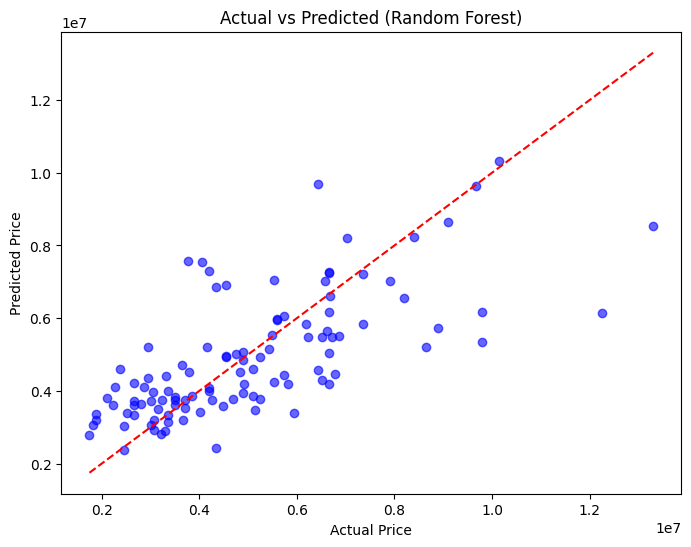

In [57]:
# ============================================
# 8️⃣ Actual vs Predicted Plot (For Best Model)
# ============================================
# Example: Random Forest
best_model = RandomForestRegressor(random_state=42)
best_model.fit(x_train_raw, y_train)
y_pred_best = best_model.predict(x_test_raw)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [58]:
# ============================================
# 9️⃣ User Input Prediction Example
# ============================================
# Suppose new house details
new_house = pd.DataFrame({
    "area": [3500],
    "bedrooms": [4],
    "bathrooms": [3],
    "stories": [2],
    "parking": [2]
})

# Tree-based model prediction
pred_price_tree = best_model.predict(new_house)
print("\nPredicted Price (Random Forest):", round(pred_price_tree[0],2))

# Distance-based models prediction
new_scaled = scaler.transform(new_house)
svr_model = SVR()
svr_model.fit(x_train_scaled, y_train)
pred_price_svr = svr_model.predict(new_scaled)
print("Predicted Price (SVR):", round(pred_price_svr[0],2))


Predicted Price (Random Forest): 6930700.0
Predicted Price (SVR): 4291011.68


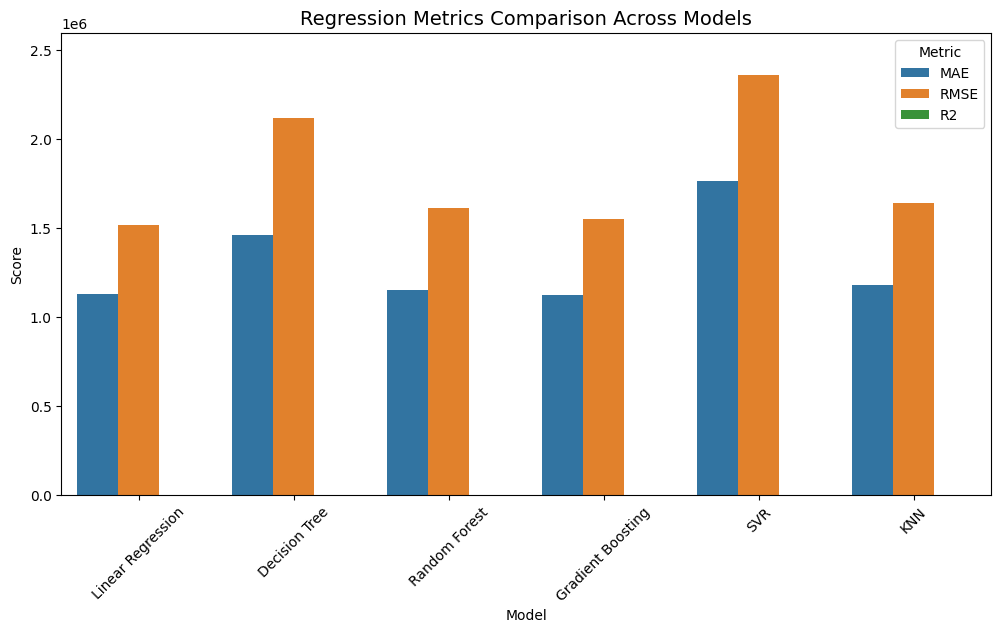

In [60]:
# ============================================
# 3️⃣ Multi-metrics comparison graph
# ============================================
# Melt dataframe for seaborn
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted)
plt.title("Regression Metrics Comparison Across Models", fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, max(df_melted["Score"])*1.1)
plt.legend(title="Metric")
plt.show()